<a href="https://colab.research.google.com/github/23SCSE1010436/DDOS-Attack-Dection/blob/main/DDoS_Detection_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install matplotlib seaborn pandas numpy scikit-learn plotly tabulate tqdm requests -q

In [2]:
import random, time, json, csv, ipaddress, requests
from datetime import datetime
from collections import deque
from dataclasses import dataclass, field
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from tabulate import tabulate
from tqdm import tqdm

print(f'System ready — {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

System ready — 2026-05-14 05:28:59


In [3]:
# ── CONFIGURATION ─────────────────────────────────────────────────────────────
CONFIG = {
    'PACKET_THRESHOLD_PER_SEC' : 100,
    'SYN_FLOOD_THRESHOLD'      : 200,
    'UDP_FLOOD_THRESHOLD'      : 500,
    'ICMP_FLOOD_THRESHOLD'     : 300,
    'HTTP_FLOOD_THRESHOLD'     : 150,
    'DETECTION_WINDOW_SEC'     : 10,
    'BLACKLIST_DURATION_SEC'   : 300,
    'ML_CONTAMINATION'         : 0.1,
    'SIMULATION_PACKETS'       : 5000,
    'ATTACK_PROBABILITY'       : 0.25,
    'NUM_LEGITIMATE_IPS'       : 50,
    'NUM_ATTACKER_IPS'         : 10,
    'HTTP_PORTS'               : [80, 8080, 443, 8443],
    'DNS_PORT'                 : 53,
    'NTP_PORT'                 : 123,
}

ATTACK_TYPES = {
    'SYN_FLOOD'  : {'name': 'SYN Flood',          'color': '#FF4444', 'icon': '🔴'},
    'UDP_FLOOD'  : {'name': 'UDP Flood',          'color': '#FF8800', 'icon': '🟠'},
    'ICMP_FLOOD' : {'name': 'ICMP Flood',         'color': '#FFBB00', 'icon': '🟡'},
    'HTTP_FLOOD' : {'name': 'HTTP Flood',         'color': '#FF44AA', 'icon': '🟣'},
    'DNS_AMP'    : {'name': 'DNS Amplification',  'color': '#AA00FF', 'icon': '🔵'},
    'NTP_AMP'    : {'name': 'NTP Amplification',  'color': '#0044FF', 'icon': '💙'},
    'NORMAL'     : {'name': 'Normal Traffic',     'color': '#00CC66', 'icon': '🟢'},
}

SEV_COLORS = {'CRITICAL': '#CC0000', 'HIGH': '#FF6600', 'MEDIUM': '#FFB300', 'LOW': '#00AA44'}
print('Configuration loaded.')

Configuration loaded.


In [4]:
# ── DATA MODELS ───────────────────────────────────────────────────────────────
@dataclass
class Packet:
    timestamp   : float
    src_ip      : str
    dst_ip      : str
    src_port    : int
    dst_port    : int
    protocol    : str
    size        : int
    flags       : str  = ''
    payload_len : int  = 0
    is_attack   : bool = False
    attack_type : str  = 'NORMAL'

@dataclass
class IPProfile:
    ip             : str
    packet_times   : deque = field(default_factory=lambda: deque(maxlen=10000))
    byte_times     : deque = field(default_factory=lambda: deque(maxlen=10000))
    syn_times      : deque = field(default_factory=lambda: deque(maxlen=10000))
    udp_times      : deque = field(default_factory=lambda: deque(maxlen=10000))
    icmp_times     : deque = field(default_factory=lambda: deque(maxlen=10000))
    http_times     : deque = field(default_factory=lambda: deque(maxlen=10000))
    total_packets  : int   = 0
    total_bytes    : int   = 0
    alert_count    : int   = 0
    is_blacklisted : bool  = False
    blacklist_until: Optional[float] = None
    country        : str   = 'Unknown'
    first_seen     : float = field(default_factory=time.time)
    last_seen      : float = field(default_factory=time.time)

@dataclass
class Alert:
    timestamp    : float
    src_ip       : str
    attack_type  : str
    severity     : str
    packet_rate  : float
    description  : str
    action_taken : str

print('Data models ready.')

Data models ready.


In [5]:
# ── GEO-IP RESOLVER ───────────────────────────────────────────────────────────
class GeoIPResolver:
    COUNTRY_MAP = [
        ('1.'  , 'US', 'United States'),
        ('2.'  , 'CN', 'China'),
        ('3.'  , 'RU', 'Russia'),
        ('4.'  , 'DE', 'Germany'),
        ('5.'  , 'BR', 'Brazil'),
        ('6.'  , 'IN', 'India'),
        ('7.'  , 'GB', 'United Kingdom'),
        ('8.'  , 'FR', 'France'),
        ('9.'  , 'JP', 'Japan'),
        ('10.' , 'KR', 'South Korea'),
        ('11.' , 'NL', 'Netherlands'),
        ('12.' , 'UA', 'Ukraine'),
        ('13.' , 'IR', 'Iran'),
        ('14.' , 'TR', 'Turkey'),
        ('15.' , 'IT', 'Italy'),
        ('192.', 'US', 'United States (Private)'),
        ('172.', 'XX', 'Private Network'),
        ('10.' , 'XX', 'Private Network'),
    ]
    COORDS = {
        'US':(37.09,-95.71),'CN':(35.86,104.19),'RU':(61.52,105.31),
        'DE':(51.16,10.45), 'BR':(-14.23,-51.92),'IN':(20.59,78.96),
        'GB':(55.37,-3.43), 'FR':(46.22,2.21),  'JP':(36.20,138.25),
        'KR':(35.90,127.76),'NL':(52.13,5.29),  'UA':(48.38,31.16),
        'IR':(32.42,53.68), 'TR':(38.96,35.24), 'IT':(41.87,12.56),
        'XX':(0,0),
    }
    HIGH_RISK = {'CN','RU','IR','KP','SY'}

    def __init__(self):
        self._cache: Dict[str, dict] = {}

    def lookup(self, ip: str) -> dict:
        if ip in self._cache:
            return self._cache[ip]
        cc, cn = 'XX', 'Unknown'
        for prefix, c, name in self.COUNTRY_MAP:
            if ip.startswith(prefix):
                cc, cn = c, name
                break
        else:
            _, c, name = random.choice(self.COUNTRY_MAP)
            cc, cn = c, name
        lat, lon = self.COORDS.get(cc, (0, 0))
        lat += random.uniform(-4, 4)
        lon += random.uniform(-4, 4)
        result = {
            'ip': ip, 'country_code': cc, 'country_name': cn,
            'lat': round(lat, 4), 'lon': round(lon, 4),
            'is_high_risk': cc in self.HIGH_RISK,
            'is_private': self._is_private(ip),
        }
        self._cache[ip] = result
        return result

    @staticmethod
    def _is_private(ip: str) -> bool:
        try: return ipaddress.ip_address(ip).is_private
        except: return False

geo = GeoIPResolver()
test = geo.lookup('8.8.8.8')
print(f'GeoIP ready — 8.8.8.8 → {test["country_name"]}')

GeoIP ready — 8.8.8.8 → France


In [6]:
# ── TRAFFIC SIMULATOR ─────────────────────────────────────────────────────────
class TrafficSimulator:
    TCP_FLAGS = ['SYN','ACK','SYN-ACK','FIN','RST','PSH-ACK']

    def __init__(self, cfg):
        self.cfg       = cfg
        self.target_ip = '192.168.1.1'
        self.legit_ips    = [self._rip('l') for _ in range(cfg['NUM_LEGITIMATE_IPS'])]
        self.attacker_ips = [self._rip('a') for _ in range(cfg['NUM_ATTACKER_IPS'])]
        self.scenarios = ['SYN_FLOOD','UDP_FLOOD','ICMP_FLOOD','HTTP_FLOOD','DNS_AMP','NTP_AMP']

    @staticmethod
    def _rip(kind):
        p = random.choice(['2.','3.','12.','13.']) if kind == 'a' else f'{random.randint(1,220)}.'
        return p + '.'.join(str(random.randint(0,255)) for _ in range(3))

    def _normal(self, t):
        proto = random.choices(['TCP','UDP','ICMP'], weights=[60,30,10])[0]
        if proto == 'TCP':
            flags = random.choice(self.TCP_FLAGS)
            dport = random.choice(self.cfg['HTTP_PORTS'] + [22,25,110,143,3306])
        elif proto == 'UDP':
            flags = ''; dport = random.choice([53,123,1194,random.randint(1024,65535)])
        else:
            flags = 'ECHO'; dport = 0
        return Packet(t, random.choice(self.legit_ips), self.target_ip,
                      random.randint(1024,65535), dport, proto,
                      random.randint(64,1500), flags, random.randint(0,1400))

    def _attack(self, t, atype, attacker):
        p = Packet(t, attacker, self.target_ip,
                   random.randint(1024,65535), 80, 'TCP', 64, 'SYN', 0, True, atype)
        if atype == 'SYN_FLOOD':
            p.protocol='TCP'; p.flags='SYN'; p.size=random.randint(40,60)
            p.dst_port=random.choice(self.cfg['HTTP_PORTS'])
        elif atype == 'UDP_FLOOD':
            p.protocol='UDP'; p.flags=''; p.size=random.randint(512,65535)
            p.dst_port=random.randint(1,65535)
        elif atype == 'ICMP_FLOOD':
            p.protocol='ICMP'; p.flags='ECHO'; p.size=random.randint(1024,65535); p.dst_port=0
        elif atype == 'HTTP_FLOOD':
            p.protocol='TCP'; p.flags='PSH-ACK'; p.size=random.randint(200,800)
            p.dst_port=80; p.payload_len=p.size-20
        elif atype == 'DNS_AMP':
            p.protocol='UDP'; p.dst_port=self.cfg['DNS_PORT']; p.size=random.randint(50,70)
        elif atype == 'NTP_AMP':
            p.protocol='UDP'; p.dst_port=self.cfg['NTP_PORT']; p.size=random.randint(90,110)
        return p

    def generate(self, n):
        packets, t = [], time.time() - n * 0.002
        active_attack = None; active_attacker = None; attack_end = 0.0
        print(f'Generating {n:,} packets...')
        for i in tqdm(range(n)):
            t += random.uniform(0.001, 0.005)
            if t > attack_end and random.random() < self.cfg['ATTACK_PROBABILITY'] / 50:
                active_attack   = random.choice(self.scenarios)
                active_attacker = random.choice(self.attacker_ips)
                attack_end      = t + random.uniform(5, 30)
            if t > attack_end:
                active_attack = None
            if active_attack and random.random() < 0.7:
                for _ in range(random.randint(5, 20)):
                    packets.append(self._attack(t, active_attack, active_attacker))
                    t += 0.0001
            else:
                packets.append(self._normal(t))
        packets.sort(key=lambda p: p.timestamp)
        att = sum(1 for p in packets if p.is_attack)
        print(f'Done — {len(packets):,} total | Normal: {len(packets)-att:,} | Attack: {att:,}')
        return packets

sim = TrafficSimulator(CONFIG)
print('Simulator ready.')

Simulator ready.


In [7]:
# ── DETECTION ENGINE ──────────────────────────────────────────────────────────
class DetectionEngine:
    def __init__(self, cfg):
        self.cfg        = cfg
        self.profiles   : Dict[str, IPProfile] = {}
        self.blacklist  : Dict[str, float]     = {}
        self.alerts     : List[Alert]          = []
        self.whitelist  = {'127.0.0.1', '192.168.1.1'}
        self.w          = cfg['DETECTION_WINDOW_SEC']
        self.iso        = IsolationForest(contamination=cfg['ML_CONTAMINATION'],
                                          random_state=42, n_estimators=100)
        self.scaler     = StandardScaler()
        self._trained   = False
        self.packet_log : List[Packet] = []

    def _profile(self, ip):
        if ip not in self.profiles:
            self.profiles[ip] = IPProfile(ip=ip)
            self.profiles[ip].country = geo.lookup(ip)['country_name']
        return self.profiles[ip]

    def _update(self, pkt):
        p = self._profile(pkt.src_ip)
        t = pkt.timestamp
        p.packet_times.append(t)
        p.byte_times.append((t, pkt.size))
        p.total_packets += 1
        p.total_bytes   += pkt.size
        p.last_seen      = t
        if pkt.protocol == 'TCP' and 'SYN' in pkt.flags and 'ACK' not in pkt.flags:
            p.syn_times.append(t)
        if pkt.protocol == 'UDP':  p.udp_times.append(t)
        if pkt.protocol == 'ICMP': p.icmp_times.append(t)
        if pkt.dst_port in self.cfg['HTTP_PORTS']: p.http_times.append(t)

    @staticmethod
    def _rate(times, window, now):
        return sum(1 for t in times if t >= now - window) / window

    def _features(self, ip, now):
        p = self._profile(ip)
        w = self.w
        return [
            self._rate(p.packet_times, w, now),
            self._rate(p.syn_times,    w, now),
            self._rate(p.udp_times,    w, now),
            self._rate(p.icmp_times,   w, now),
            self._rate(p.http_times,   w, now),
            sum(s for t, s in p.byte_times if t >= now - w) / 1e6,
        ]

    def _threshold(self, ip, now):
        p  = self._profile(ip)
        w  = self.w
        pr = self._rate(p.packet_times, w, now)
        sr = self._rate(p.syn_times,    w, now)
        ur = self._rate(p.udp_times,    w, now)
        ir = self._rate(p.icmp_times,   w, now)
        hr = self._rate(p.http_times,   w, now)
        cfg = self.cfg
        if sr > cfg['SYN_FLOOD_THRESHOLD']:  return ('SYN_FLOOD',  'CRITICAL', sr)
        if ur > cfg['UDP_FLOOD_THRESHOLD']:  return ('UDP_FLOOD',  'HIGH',     ur)
        if ir > cfg['ICMP_FLOOD_THRESHOLD']: return ('ICMP_FLOOD', 'HIGH',     ir)
        if hr > cfg['HTTP_FLOOD_THRESHOLD']: return ('HTTP_FLOOD', 'MEDIUM',   hr)
        if pr > cfg['PACKET_THRESHOLD_PER_SEC']: return ('UNKNOWN_FLOOD','MEDIUM',pr)
        return None

    def _check_bl(self, ip, now):
        if ip in self.blacklist:
            if now < self.blacklist[ip]: return True
            del self.blacklist[ip]
            self.profiles[ip].is_blacklisted = False
        return False

    def _ban(self, ip, now):
        exp = now + self.cfg['BLACKLIST_DURATION_SEC']
        self.blacklist[ip] = exp
        self._profile(ip).is_blacklisted  = True
        self._profile(ip).blacklist_until = exp

    def process(self, pkt):
        ip, now = pkt.src_ip, pkt.timestamp
        if ip in self.whitelist: return None
        if self._check_bl(ip, now): return None
        self._update(pkt)
        self.packet_log.append(pkt)
        result = self._threshold(ip, now)
        if result:
            atype, sev, rate = result
            self._profile(ip).alert_count += 1
            action = f'IP {ip} BLACKLISTED' if sev == 'CRITICAL' else 'RATE LIMITED'
            if sev == 'CRITICAL': self._ban(ip, now)
            alert = Alert(now, ip, atype, sev, round(rate,2),
                          f'{ATTACK_TYPES.get(atype,{}).get("name",atype)} from {ip} @ {rate:.1f} pkt/s',
                          action)
            self.alerts.append(alert)
            return alert
        return None

    def train_ml(self):
        now = time.time()
        X = np.array([self._features(ip, now) for ip in self.profiles])
        Xs = self.scaler.fit_transform(X)
        self.iso.fit(Xs)
        self._trained = True
        print(f'ML model trained on {len(X)} IP profiles.')

    def ml_anomaly(self, ip):
        if not self._trained: return False
        f = np.array([self._features(ip, time.time())])
        return self.iso.predict(self.scaler.transform(f))[0] == -1

engine = DetectionEngine(CONFIG)
print('Detection engine ready.')

Detection engine ready.


In [8]:
# ── RUN SIMULATION ────────────────────────────────────────────────────────────
packets = sim.generate(CONFIG['SIMULATION_PACKETS'])

print('\nProcessing packets through detection engine...')
for pkt in tqdm(packets, desc='Analysing'):
    engine.process(pkt)

print('\nTraining ML model...')
engine.train_ml()
ml_hits = [ip for ip in engine.profiles if engine.ml_anomaly(ip)]

# Summary
df = pd.DataFrame([{
    'timestamp'  : p.timestamp, 'src_ip': p.src_ip,
    'protocol'   : p.protocol,  'size'  : p.size,
    'is_attack'  : p.is_attack, 'attack_type': p.attack_type,
    'dst_port'   : p.dst_port,
} for p in packets])
df['dt']     = pd.to_datetime(df['timestamp'], unit='s')
df['second'] = df['dt'].dt.floor('S')

att  = int(df['is_attack'].sum())
norm = len(df) - att

seen_alert = set()
unique_alerts = []
for a in engine.alerts:
    k = (a.src_ip, a.attack_type)
    if k not in seen_alert:
        seen_alert.add(k); unique_alerts.append(a)
unique_alerts.sort(key=lambda x: x.timestamp, reverse=True)

rows = [
    ['Total Packets',          f'{len(df):,}'],
    ['Normal Packets',         f'{norm:,}'],
    ['Attack Packets',         f'{att:,}'],
    ['Unique IPs',             len(engine.profiles)],
    ['Unique Alerts Fired',    len(unique_alerts)],
    ['IPs Blacklisted',        len(engine.blacklist)],
    ['ML Anomalies',           len(ml_hits)],
]
print('\n' + tabulate(rows, headers=['Metric','Value'], tablefmt='rounded_outline'))

Generating 5,000 packets...


100%|██████████| 5000/5000 [00:00<00:00, 13128.33it/s]


Done — 43,978 total | Normal: 1,608 | Attack: 42,370

Processing packets through detection engine...


Analysing: 100%|██████████| 43978/43978 [01:03<00:00, 697.89it/s]



Training ML model...
ML model trained on 52 IP profiles.

╭─────────────────────┬─────────╮
│ Metric              │ Value   │
├─────────────────────┼─────────┤
│ Total Packets       │ 43,978  │
│ Normal Packets      │ 1,608   │
│ Attack Packets      │ 42,370  │
│ Unique IPs          │ 52      │
│ Unique Alerts Fired │ 5       │
│ IPs Blacklisted     │ 1       │
│ ML Anomalies        │ 0       │
╰─────────────────────┴─────────╯


/tmp/ipykernel_1447/4074119320.py:20: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df['second'] = df['dt'].dt.floor('S')


In [9]:
# ── ALERT TABLE ───────────────────────────────────────────────────────────────
SEV_ICON = {'CRITICAL':'🔴','HIGH':'🟠','MEDIUM':'🟡','LOW':'🟢'}
rows = []
for a in unique_alerts[:30]:
    g = geo.lookup(a.src_ip)
    rows.append([
        datetime.fromtimestamp(a.timestamp).strftime('%H:%M:%S'),
        a.src_ip,
        g['country_name'][:16],
        SEV_ICON.get(a.severity,'') + ' ' + a.severity,
        ATTACK_TYPES.get(a.attack_type,{}).get('name', a.attack_type),
        f'{a.packet_rate} pkt/s',
        a.action_taken[:28],
    ])
print(tabulate(rows,
    headers=['Time','Source IP','Country','Severity','Attack Type','Rate','Action'],
    tablefmt='rounded_outline'))

╭──────────┬────────────────┬───────────┬─────────────┬───────────────┬─────────────┬──────────────────────────────╮
│ Time     │ Source IP      │ Country   │ Severity    │ Attack Type   │ Rate        │ Action                       │
├──────────┼────────────────┼───────────┼─────────────┼───────────────┼─────────────┼──────────────────────────────┤
│ 05:29:36 │ 12.10.246.244  │ Ukraine   │ 🟠 HIGH     │ UDP Flood     │ 500.1 pkt/s │ RATE LIMITED                 │
│ 05:29:34 │ 12.10.246.244  │ Ukraine   │ 🟡 MEDIUM   │ UNKNOWN_FLOOD │ 100.1 pkt/s │ RATE LIMITED                 │
│ 05:29:29 │ 13.210.171.179 │ Iran      │ 🔴 CRITICAL │ SYN Flood     │ 200.1 pkt/s │ IP 13.210.171.179 BLACKLISTE │
│ 05:29:29 │ 13.210.171.179 │ Iran      │ 🟡 MEDIUM   │ HTTP Flood    │ 150.1 pkt/s │ RATE LIMITED                 │
│ 05:29:29 │ 13.210.171.179 │ Iran      │ 🟡 MEDIUM   │ UNKNOWN_FLOOD │ 100.1 pkt/s │ RATE LIMITED                 │
╰──────────┴────────────────┴───────────┴─────────────┴──────────────

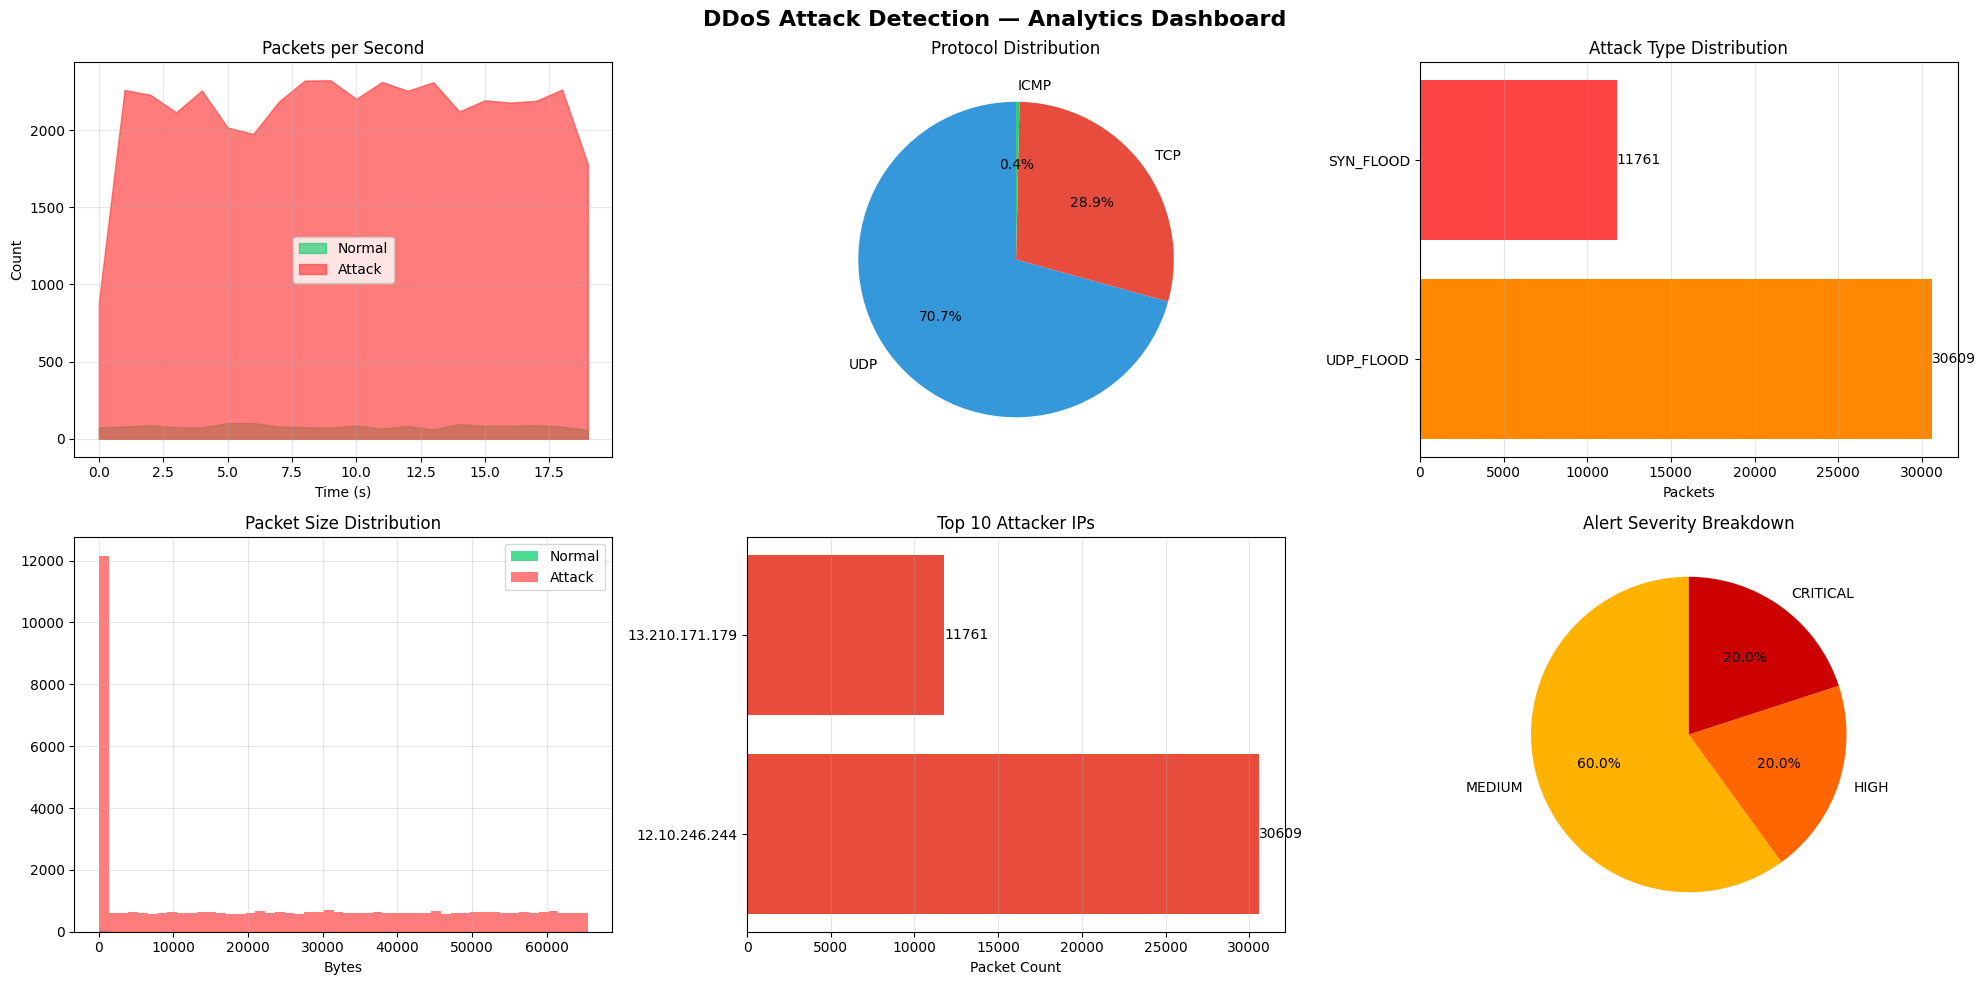

In [10]:
# ── DASHBOARD (matplotlib) ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('DDoS Attack Detection — Analytics Dashboard', fontsize=16, fontweight='bold')

# 1 — Packets per second
ax = axes[0,0]
pps = df.groupby(['second','is_attack']).size().unstack(fill_value=0)
if False in pps.columns: ax.fill_between(range(len(pps)), pps[False], alpha=0.6, color='#00CC66', label='Normal')
if True  in pps.columns: ax.fill_between(range(len(pps)), pps[True],  alpha=0.7, color='#FF4444', label='Attack')
ax.set_title('Packets per Second'); ax.set_xlabel('Time (s)'); ax.set_ylabel('Count')
ax.legend(); ax.grid(alpha=0.3)

# 2 — Protocol pie
ax = axes[0,1]
pc = df['protocol'].value_counts()
ax.pie(pc, labels=pc.index, autopct='%1.1f%%', colors=['#3498DB','#E74C3C','#2ECC71'], startangle=90)
ax.set_title('Protocol Distribution')

# 3 — Attack types
ax = axes[0,2]
adf = df[df['is_attack']]
if not adf.empty:
    tc = adf['attack_type'].value_counts()
    clrs = [ATTACK_TYPES.get(t,{}).get('color','#888') for t in tc.index]
    bars = ax.barh(tc.index, tc.values, color=clrs)
    ax.bar_label(bars)
ax.set_title('Attack Type Distribution'); ax.set_xlabel('Packets'); ax.grid(axis='x', alpha=0.3)

# 4 — Packet size
ax = axes[1,0]
ax.hist(df[~df['is_attack']]['size'], bins=50, alpha=0.7, color='#00CC66', label='Normal')
ax.hist(df[df['is_attack']]['size'],  bins=50, alpha=0.7, color='#FF4444', label='Attack')
ax.set_title('Packet Size Distribution'); ax.set_xlabel('Bytes'); ax.legend(); ax.grid(alpha=0.3)

# 5 — Top attacker IPs
ax = axes[1,1]
ta = df[df['is_attack']].groupby('src_ip').size().nlargest(10).reset_index(name='count')
if not ta.empty:
    bars = ax.barh(ta['src_ip'], ta['count'], color='#E74C3C')
    ax.bar_label(bars)
ax.set_title('Top 10 Attacker IPs'); ax.set_xlabel('Packet Count'); ax.grid(axis='x', alpha=0.3)

# 6 — Alert severity
ax = axes[1,2]
if unique_alerts:
    sd = pd.Series([a.severity for a in unique_alerts]).value_counts()
    clrs2 = [SEV_COLORS.get(s,'#888') for s in sd.index]
    ax.pie(sd, labels=sd.index, autopct='%1.1f%%', colors=clrs2, startangle=90)
ax.set_title('Alert Severity Breakdown')

plt.tight_layout()
plt.savefig('ddos_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# ── INTERACTIVE PLOTLY DASHBOARD ──────────────────────────────────────────────
fig2 = make_subplots(rows=2, cols=2,
    subplot_titles=['Traffic Volume','Bandwidth (MB/s)','Alert Timeline','Top-20 IPs by Packets'])

n_pps = df[~df['is_attack']].groupby('second').size().reset_index(name='c')
a_pps = df[df['is_attack']].groupby('second').size().reset_index(name='c')
fig2.add_trace(go.Scatter(x=n_pps['second'], y=n_pps['c'], fill='tozeroy', name='Normal',  line=dict(color='#00CC66')), 1,1)
fig2.add_trace(go.Scatter(x=a_pps['second'], y=a_pps['c'], fill='tozeroy', name='Attack',  line=dict(color='#FF4444')), 1,1)

bw = df.groupby('second')['size'].sum().reset_index(name='b')
bw['mb'] = bw['b']/1e6
fig2.add_trace(go.Scatter(x=bw['second'], y=bw['mb'], fill='tozeroy', name='MB/s', line=dict(color='#3498DB')), 1,2)

if unique_alerts:
    at = [datetime.fromtimestamp(a.timestamp) for a in unique_alerts]
    fig2.add_trace(go.Scatter(
        x=at, y=[a.attack_type for a in unique_alerts],
        mode='markers',
        marker=dict(color=[SEV_COLORS.get(a.severity,'#888') for a in unique_alerts], size=10, symbol='diamond'),
        text=[f'{a.src_ip} | {a.severity}' for a in unique_alerts],
        hovertemplate='<b>%{text}</b><br>%{x}<extra></extra>', name='Alert'), 2,1)

t20 = df.groupby('src_ip').size().nlargest(20).reset_index(name='c')
fig2.add_trace(go.Bar(x=t20['src_ip'], y=t20['c'], name='Packets', marker_color='#9B59B6'), 2,2)

fig2.update_layout(title='DDoS Detection — Interactive Dashboard', height=700,
    paper_bgcolor='#1a1a2e', plot_bgcolor='#16213e', font=dict(color='#eee'))
fig2.show()

In [12]:
# ── GEO-IP WORLD MAP ──────────────────────────────────────────────────────────
attacker_set = {p.src_ip for p in packets if p.is_attack}
geo_rows = []
for ip in list(attacker_set)[:300]:
    g   = geo.lookup(ip)
    cnt = sum(1 for p in packets if p.src_ip == ip and p.is_attack)
    geo_rows.append({'ip':ip,'country':g['country_name'],
                     'lat':g['lat'],'lon':g['lon'],
                     'count':cnt,'risk':g['is_high_risk']})
gdf = pd.DataFrame(geo_rows)

fig_map = go.Figure(go.Scattergeo(
    lat=gdf['lat'], lon=gdf['lon'],
    text=gdf.apply(lambda r: f"{r['ip']}<br>{r['country']}<br>{r['count']} pkts", axis=1),
    mode='markers',
    marker=dict(
        size=np.log1p(gdf['count'])*3+5,
        color=['#FF2222' if r else '#FF8800' for r in gdf['risk']],
        opacity=0.85, line=dict(width=1, color='white')),
    hovertemplate='<b>%{text}</b><extra></extra>',
))
fig_map.update_layout(
    title='DDoS Attack Origin Map',
    geo=dict(showland=True, landcolor='#1a3a2a', showocean=True, oceancolor='#0a1628',
             showframe=False, showcountries=True, countrycolor='#444', bgcolor='#0a1628'),
    paper_bgcolor='#0a1628', font=dict(color='white'), height=520)
fig_map.show()
print(f'Map rendered for {len(gdf)} attacker IPs.')

Map rendered for 2 attacker IPs.


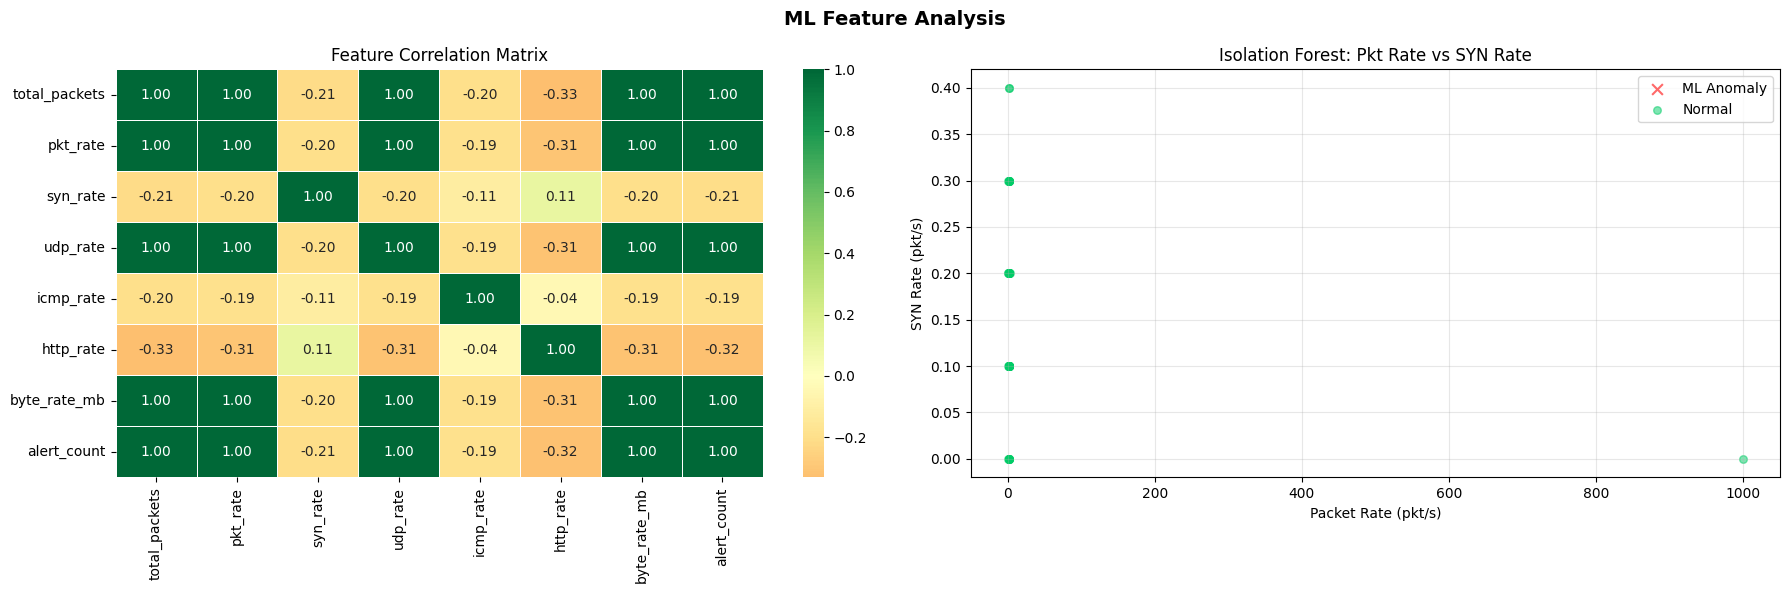

Anomalies flagged: 0 / 52 IPs


In [13]:
# ── ML FEATURE ANALYSIS ───────────────────────────────────────────────────────
now_ts = max(p.timestamp for p in packets)
feat_rows = []
for ip, prof in engine.profiles.items():
    g = geo.lookup(ip)
    f = engine._features(ip, now_ts)
    feat_rows.append({
        'ip':ip,'country':g['country_name'],'is_high_risk':g['is_high_risk'],
        'total_packets':prof.total_packets,'total_bytes':prof.total_bytes,
        'alert_count':prof.alert_count,'blacklisted':prof.is_blacklisted,
        'pkt_rate':f[0],'syn_rate':f[1],'udp_rate':f[2],
        'icmp_rate':f[3],'http_rate':f[4],'byte_rate_mb':f[5],
        'is_attacker': any(p.is_attack for p in packets if p.src_ip == ip),
        'ml_anomaly': engine.ml_anomaly(ip),
    })
fdf = pd.DataFrame(feat_rows)

num_cols = ['total_packets','pkt_rate','syn_rate','udp_rate','icmp_rate','http_rate','byte_rate_mb','alert_count']
fig3, axes = plt.subplots(1, 2, figsize=(18, 6))
fig3.suptitle('ML Feature Analysis', fontsize=14, fontweight='bold')

sns.heatmap(fdf[num_cols].corr(), annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Feature Correlation Matrix')

axes[1].scatter(fdf[fdf['ml_anomaly']]['pkt_rate'],  fdf[fdf['ml_anomaly']]['syn_rate'],
                c='#FF4444', label='ML Anomaly', alpha=0.8, s=60, marker='x')
axes[1].scatter(fdf[~fdf['ml_anomaly']]['pkt_rate'], fdf[~fdf['ml_anomaly']]['syn_rate'],
                c='#00CC66', label='Normal',     alpha=0.5, s=30)
axes[1].set_title('Isolation Forest: Pkt Rate vs SYN Rate')
axes[1].set_xlabel('Packet Rate (pkt/s)'); axes[1].set_ylabel('SYN Rate (pkt/s)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ml_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Anomalies flagged: {fdf["ml_anomaly"].sum()} / {len(fdf)} IPs')

In [14]:
# ── IP INTELLIGENCE REPORT ────────────────────────────────────────────────────
def ip_report(ip: str):
    g    = geo.lookup(ip)
    prof = engine.profiles.get(ip)
    if not prof:
        print(f'{ip} — not seen in this session.'); return

    ip_pkts = [p for p in packets if p.src_ip == ip]
    att_pkts = [p for p in ip_pkts if p.is_attack]
    now = max((p.timestamp for p in ip_pkts), default=time.time())
    f   = engine._features(ip, now)

    rows = [
        ['IP Address',    ip],
        ['Country',       g['country_name']],
        ['Coordinates',   f"({g['lat']}, {g['lon']})"],
        ['High-Risk',     '⚠️ YES' if g['is_high_risk'] else '✅ NO'],
        ['Private IP',    '✅ YES' if g['is_private']   else '❌ NO'],
        ['---','---'],
        ['Total Packets', f'{prof.total_packets:,}'],
        ['Total Bytes',   f'{prof.total_bytes/1e6:.2f} MB'],
        ['Pkt Rate',      f'{f[0]:.1f} pkt/s'],
        ['SYN Rate',      f'{f[1]:.1f} pkt/s'],
        ['UDP Rate',      f'{f[2]:.1f} pkt/s'],
        ['ICMP Rate',     f'{f[3]:.1f} pkt/s'],
        ['HTTP Rate',     f'{f[4]:.1f} req/s'],
        ['---','---'],
        ['Alerts',        prof.alert_count],
        ['Blacklisted',   '🔴 YES' if prof.is_blacklisted else '🟢 NO'],
        ['ML Anomaly',    '⚠️ YES' if engine.ml_anomaly(ip) else '✅ NO'],
        ['Attack Pkts',   f'{len(att_pkts):,} / {len(ip_pkts):,}'],
    ]
    print('=' * 55)
    print(f'  IP INTELLIGENCE: {ip}')
    print('=' * 55)
    print(tabulate(rows, headers=['Field','Value'], tablefmt='rounded_outline'))

    types = pd.Series([p.attack_type for p in att_pkts]).value_counts()
    if not types.empty:
        print('\n  Attack Breakdown:')
        for t, c in types.items():
            icon = ATTACK_TYPES.get(t,{}).get('icon','?')
            print(f'  {icon} {ATTACK_TYPES.get(t,{}).get("name",t):25s} {c:,} packets')

    ip_alerts = [a for a in engine.alerts if a.src_ip == ip]
    if ip_alerts:
        print(f'\n  Alerts ({len(ip_alerts)}):')
        for a in ip_alerts[:5]:
            print(f'  [{datetime.fromtimestamp(a.timestamp).strftime("%H:%M:%S")}] '
                  f'{a.severity:8s} | {a.attack_type:15s} | {a.action_taken}')

# Run on the biggest attacker
top_ip = df[df['is_attack']].groupby('src_ip').size().idxmax() if att > 0 else None
if top_ip: ip_report(top_ip)

  IP INTELLIGENCE: 12.10.246.244
╭───────────────┬────────────────────╮
│ Field         │ Value              │
├───────────────┼────────────────────┤
│ IP Address    │ 12.10.246.244      │
│ Country       │ Ukraine            │
│ Coordinates   │ (48.1551, 28.9427) │
│ High-Risk     │ ✅ NO              │
│ Private IP    │ ❌ NO              │
│ ---           │ ---                │
│ Total Packets │ 30,609             │
│ Total Bytes   │ 1015.60 MB         │
│ Pkt Rate      │ 1000.0 pkt/s       │
│ SYN Rate      │ 0.0 pkt/s          │
│ UDP Rate      │ 1000.0 pkt/s       │
│ ICMP Rate     │ 0.0 pkt/s          │
│ HTTP Rate     │ 0.0 req/s          │
│ ---           │ ---                │
│ Alerts        │ 29609              │
│ Blacklisted   │ 🟢 NO              │
│ ML Anomaly    │ ✅ NO              │
│ Attack Pkts   │ 30,609 / 30,609    │
╰───────────────┴────────────────────╯

  Attack Breakdown:
  🟠 UDP Flood                 30,609 packets

  Alerts (29609):
  [05:29:34] MEDIUM   | UNKN

In [16]:
# ── EXPORT REPORTS ────────────────────────────────────────────────────────────
ts = datetime.now().strftime('%Y%m%d_%H%M%S')

# Alerts CSV
with open(f'alerts_{ts}.csv','w',newline='') as f:
    w = csv.writer(f)
    w.writerow(['Timestamp','Source_IP','Country','Attack_Type','Severity','Rate','Action'])
    for a in engine.alerts:
        g = geo.lookup(a.src_ip)
        w.writerow([datetime.fromtimestamp(a.timestamp).isoformat(),
                    a.src_ip, g['country_name'], a.attack_type, a.severity,
                    a.packet_rate, a.action_taken])
print(f'alerts_{ts}.csv — {len(engine.alerts)} records')

# IP profiles CSV
fdf.to_csv(f'ip_profiles_{ts}.csv', index=False)
print(f'ip_profiles_{ts}.csv — {len(fdf)} IPs')

# Blacklist CSV
with open(f'blacklist_{ts}.csv','w',newline='') as f:
    w = csv.writer(f)
    w.writerow(['IP','Blacklisted_Until','Country'])
    for ip, exp in engine.blacklist.items():
        g = geo.lookup(ip)
        w.writerow([ip, datetime.fromtimestamp(exp).isoformat(), g['country_name']])
print(f'blacklist_{ts}.csv — {len(engine.blacklist)} IPs')

# JSON summary
with open(f'summary_{ts}.json','w') as f:
    json.dump({
        'run_time'         : datetime.now().isoformat(),
        'total_packets'    : len(packets),
        'attack_packets'   : att,
        'normal_packets'   : norm,
        'unique_ips'       : len(engine.profiles),
        'total_alerts'     : len(engine.alerts),
        'blacklisted_ips'  : len(engine.blacklist),
        'ml_anomalies'     : len(ml_hits),
        'attack_type_counts': df[df['is_attack']]['attack_type'].value_counts().to_dict(),
        'top_5_attackers'  : df[df['is_attack']].groupby('src_ip').size().nlargest(5).to_dict(),
    }, f, indent=2)
print(f'summary_{ts}.json')
print('\nAll reports exported.')

alerts_20260514_053215.csv — 30610 records
ip_profiles_20260514_053215.csv — 52 IPs
blacklist_20260514_053215.csv — 1 IPs
summary_20260514_053215.json

All reports exported.


In [15]:
# ── INTERACTIVE IP LOOKUP ─────────────────────────────────────────────────────
print('Top 15 IPs seen this session:\n')
top15 = df.groupby('src_ip').size().nlargest(15)
for i, (ip, cnt) in enumerate(top15.items(), 1):
    kind = 'Attack' if any(p.is_attack for p in packets if p.src_ip == ip) else 'Normal'
    bl   = '🔴 BLACKLISTED' if ip in engine.blacklist else ''
    print(f'  {i:2d}. {ip:20s}  {cnt:6,} pkts  {kind:8s}  {bl}')

print('\nTo inspect any IP:')
print('  ip_report("x.x.x.x")')
if len(top15) > 1:
    print(f'\nExample: ip_report("{top15.index[1]}")')

Top 15 IPs seen this session:

   1. 12.10.246.244         30,609 pkts  Attack    
   2. 13.210.171.179        11,761 pkts  Attack    🔴 BLACKLISTED
   3. 124.73.177.41             50 pkts  Normal    
   4. 112.186.55.23             42 pkts  Normal    
   5. 193.233.53.75             42 pkts  Normal    
   6. 55.35.20.147              41 pkts  Normal    
   7. 99.18.92.218              41 pkts  Normal    
   8. 187.200.230.250           39 pkts  Normal    
   9. 127.36.171.15             37 pkts  Normal    
  10. 190.182.76.229            37 pkts  Normal    
  11. 8.76.255.46               36 pkts  Normal    
  12. 97.183.19.209             36 pkts  Normal    
  13. 127.13.88.87              35 pkts  Normal    
  14. 149.78.223.101            35 pkts  Normal    
  15. 161.90.136.166            35 pkts  Normal    

To inspect any IP:
  ip_report("x.x.x.x")

Example: ip_report("13.210.171.179")
